In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
data = pd.read_csv("student_data.csv")

In [6]:
numeric_df = data.select_dtypes(include=['int64', 'float64'])


In [7]:
correlation_matrix = numeric_df.corr()

In [8]:
correlation_with_g3 = correlation_matrix['G3'].sort_values(ascending=False)
print(correlation_with_g3)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


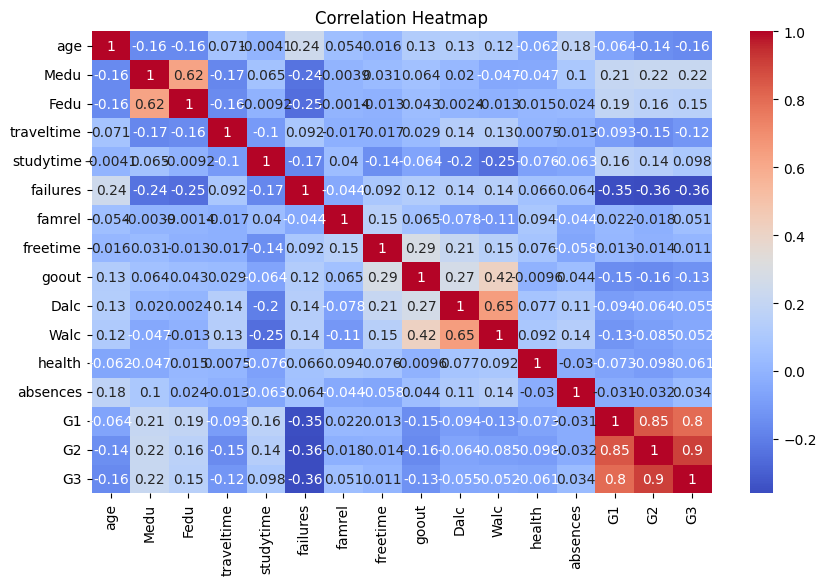

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [11]:
# Step 1: Choose your numeric features
numeric_features = ['G1', 'G2', 'failures', 'Medu', 'studytime', 'Fedu', 'absences']

In [12]:
categorical_df = data.select_dtypes(include='object').copy()

In [15]:
label_encoder = LabelEncoder()
for col in categorical_df.columns:
    categorical_df[col] = label_encoder.fit_transform(categorical_df[col])

In [17]:
# Add target variable
categorical_df['G3'] = data['G3']

In [18]:
# Compute correlation of categorical (encoded variables) with G3
cat_corr = categorical_df.corr()['G3'].sort_values(ascending=False)

print("\n📊 Categorical Feature Correlation with G3:\n")
print(cat_corr)


📊 Categorical Feature Correlation with G3:

G3            1.000000
higher        0.182465
reason        0.121994
address       0.105756
sex           0.103456
Mjob          0.102082
paid          0.101996
internet      0.098483
famsize       0.081407
nursery       0.051568
Fjob          0.042286
activities    0.016100
famsup       -0.039157
school       -0.045017
Pstatus      -0.058009
guardian     -0.070109
schoolsup    -0.082788
romantic     -0.129970
Name: G3, dtype: float64


In [19]:
# Select categorical features with |r| >= 0.1
categorical_features = cat_corr[abs(cat_corr) >= 0.1].index.tolist()

In [20]:
# Remove 'G3' itself
categorical_features.remove('G3')

In [21]:
print("\n✅ Selected Categorical Features based on correlation:")
print(categorical_features)


✅ Selected Categorical Features based on correlation:
['higher', 'reason', 'address', 'sex', 'Mjob', 'paid', 'romantic']


In [22]:
# 4️⃣ Combine Selected Features
# ================================
selected_features = numeric_features + categorical_features
print("\n🎯 Final Selected Features for Model:")
print(selected_features)


🎯 Final Selected Features for Model:
['G1', 'G2', 'failures', 'Medu', 'studytime', 'Fedu', 'absences', 'higher', 'reason', 'address', 'sex', 'Mjob', 'paid', 'romantic']


In [24]:
# 5️⃣ Prepare Final Encoded Dataset
# ================================
df_selected = data[selected_features + ['G3']].copy()

In [25]:
# Encode categorical columns again in the final dataset
for col in df_selected.select_dtypes(include='object').columns:
    df_selected[col] = label_encoder.fit_transform(df_selected[col])

In [26]:
# Separate Features and Target
X = df_selected.drop(columns=['G3'])
y = df_selected['G3']

In [27]:
print("\n✅ Feature Matrix (X) Shape:", X.shape)
print("✅ Target (y) Shape:", y.shape)


✅ Feature Matrix (X) Shape: (395, 14)
✅ Target (y) Shape: (395,)


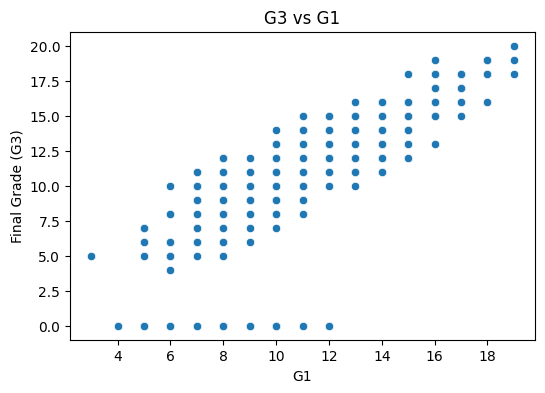

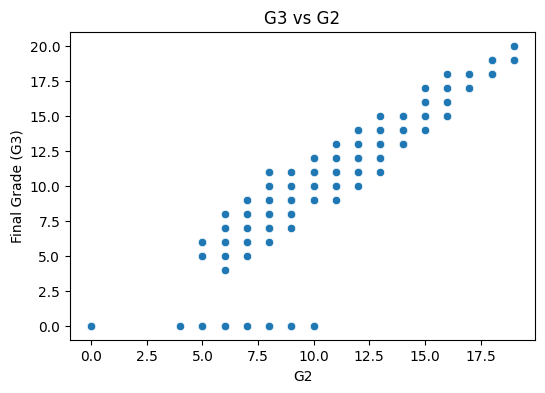

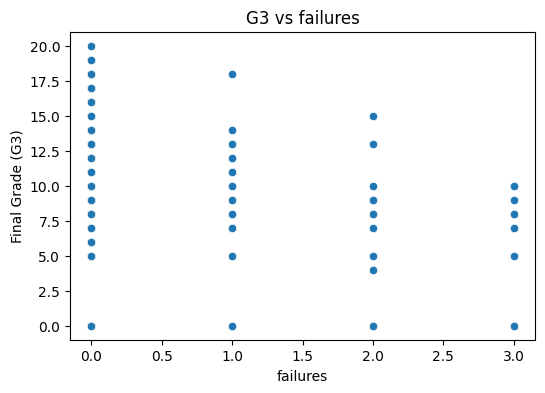

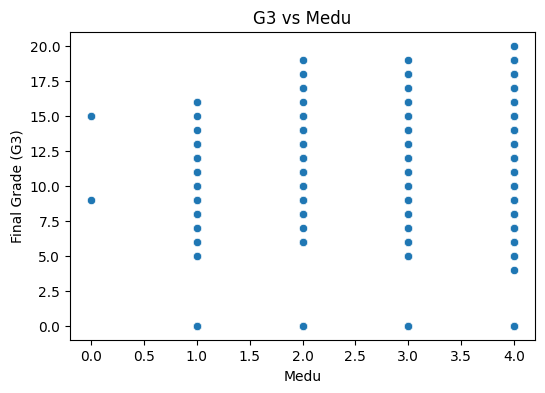

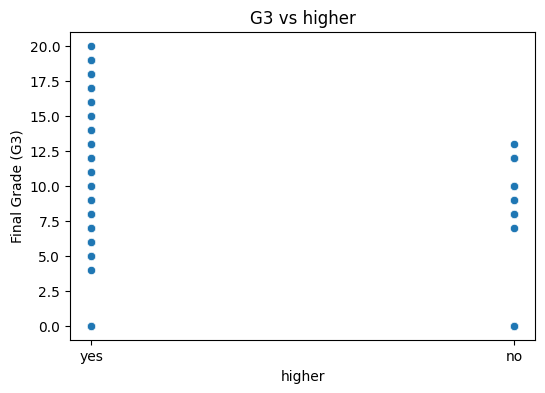

In [29]:
# Optional: Scatter plots for top correlated features
top_features = ['G1', 'G2', 'failures', 'Medu', 'higher']
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data[col], y=data['G3'])
    plt.title(f"G3 vs {col}")
    plt.xlabel(col)
    plt.ylabel("Final Grade (G3)")
    plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [43]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📉 Mean Squared Error:", mse)
print("🎯 R² Score:", r2)

📉 Mean Squared Error: 4.703328168928239
🎯 R² Score: 0.7706258314140504


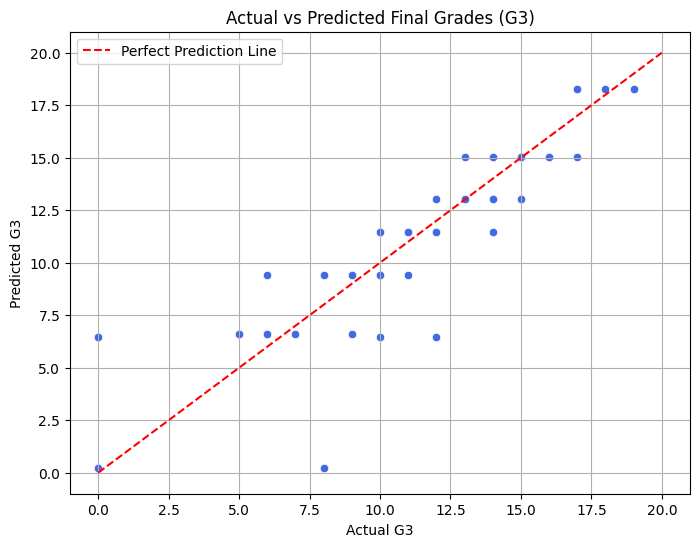

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue')
plt.plot([0, 20], [0, 20], '--', color='red', label='Perfect Prediction Line')
plt.title("Actual vs Predicted Final Grades (G3)")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# Define new students
new_students = pd.DataFrame([
    [13, 14, 0, 3, 3, 3, 2, 1, 1, 1, 1, 2, 1, 1, 1],   # Student A
    [8, 9, 2, 1, 1, 1, 10, 0, 3, 0, 0, 0, 0, 0, 1],    # Student B
    [17, 18, 0, 4, 4, 4, 1, 1, 2, 1, 1, 3, 1, 1, 1]    # Student C
], columns=['G1', 'G2', 'failures', 'Medu', 'studytime', 'Fedu', 'absences',
            'higher', 'reason', 'address', 'sex', 'Mjob', 'paid', 'internet', 'famsize'])


In [48]:
print("Model expects features:", list(X.columns))


Model expects features: ['G1', 'G2', 'failures', 'Medu', 'studytime', 'Fedu', 'absences', 'higher', 'reason', 'address', 'sex', 'Mjob', 'paid', 'romantic']


In [49]:
new_students = pd.DataFrame([
    # G1, G2, failures, Medu, studytime, Fedu, absences, higher, reason, address, sex, Mjob, paid, romantic

    # 🧍‍♂️ Student A (Good Performer)
    [13, 14, 0, 3, 3, 3, 2, 1, 1, 1, 1, 2, 1, 0],

    # 🧍‍♀️ Student B (Struggling)
    [8, 9, 2, 1, 1, 1, 10, 0, 3, 0, 0, 0, 0, 1],

    # 🧍‍♂️ Student C (Excellent)
    [17, 18, 0, 4, 4, 4, 1, 1, 2, 1, 1, 3, 1, 0]
], columns=['G1', 'G2', 'failures', 'Medu', 'studytime', 'Fedu', 'absences',
            'higher', 'reason', 'address', 'sex', 'Mjob', 'paid', 'romantic'])

# ✅ Step 2: Make predictions
predictions = model.predict(new_students)

In [50]:
# ✅ Step 3: Display the results neatly
for i, pred in enumerate(predictions, start=1):
    print(f"🎓 Student {i} predicted final grade (G3): {pred:.2f}")

🎓 Student 1 predicted final grade (G3): 15.06
🎓 Student 2 predicted final grade (G3): 9.42
🎓 Student 3 predicted final grade (G3): 18.27
